In [56]:
import pandas as pd
import numpy as np

In [57]:
!pip install koreanize_matplotlib

In [58]:
df = pd.read_excel(r'/content/drive/MyDrive/대연스포츠/과제설명_및_raw파일.xlsx', sheet_name = 'raw')

# 분석 절차
0. EDA 진행
1. 문제 정의
2. 분석 방법론 선택 & KPI 및 변수 설계
3. 모델 구축(분류로직)
4. 분류 로직 수정
5. 결과 및 인사이트 도출

#0. 0.EDA


## 0-1 구조 및 기본 정보 EDA

In [59]:
df.shape

(1975, 7)

In [60]:
df.head()

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date
0,AP,3687160000000000,WOMENS,LONG SLEEVE TOP,141,0,2024-02-05
1,AP,6084370000000000,WOMENS,LONG SLEEVE TOP,18,0,2024-08-24
2,AP,0007ffda06ba2fd4,MENS,HOODED JACKET,18,0,2024-10-10
3,FW,009f6d5e1e5d19ea,KIDS,LOW TOP,8,0,2025-02-13
4,FW,0125bec16ae27c17,WOMENS,LOW TOP,1423,234,2025-04-08


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   biz           1975 non-null   object        
 1   product_code  1975 non-null   object        
 2   gender        1975 non-null   object        
 3   silhouette    1975 non-null   object        
 4   qty           1975 non-null   int64         
 5   sale_qty      1975 non-null   int64         
 6   ship_date     1975 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 108.1+ KB


In [62]:
df.nunique()

,0
biz,2
product_code,1975
gender,3
silhouette,18
qty,603
sale_qty,293
ship_date,364


In [63]:
df['gender'].unique()

array(['WOMENS', 'MENS', 'KIDS'], dtype=object)

In [64]:
df['biz'].value_counts()

,count
biz,
AP,1121
FW,854


In [65]:
df.describe()

,qty,sale_qty,ship_date
count,1975.000000,1975.000000,1975
mean,389.816203,62.209620,2024-11-27 03:26:20.354430464
min,2.000000,-4.000000,2022-04-25 00:00:00
25%,11.000000,0.000000,2024-09-11 12:00:00
50%,45.000000,2.000000,2025-01-13 00:00:00
75%,194.500000,21.500000,2025-04-15 00:00:00
max,37446.000000,5449.000000,2025-06-20 00:00:00
std,1338.556136,235.317164,NaN


In [66]:
df['ship_date'].value_counts()

,count
ship_date,
2025-03-20,61
2025-06-18,57
2025-06-19,54
2025-05-15,53
2025-06-16,39
...,...
2024-04-03,1
2024-02-08,1
2024-01-05,1


In [67]:
df['ship_date'].min()

Timestamp('2022-04-25 00:00:00')

In [68]:
  df['ship_date'].max()

Timestamp('2025-06-20 00:00:00')

In [69]:
cond = df['ship_date'] < '2025-01-01'
df[cond]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date
0,AP,3687160000000000,WOMENS,LONG SLEEVE TOP,141,0,2024-02-05
1,AP,6084370000000000,WOMENS,LONG SLEEVE TOP,18,0,2024-08-24
2,AP,0007ffda06ba2fd4,MENS,HOODED JACKET,18,0,2024-10-10
5,AP,0139c97bf99bb290,WOMENS,SHORTS,3,0,2024-05-14
6,FW,01504a3223acef69,MENS,LOW TOP,5,0,2024-01-22
...,...,...,...,...,...,...,...
1961,AP,fe346854c1f8223c,MENS,PANTS,56,2,2024-09-25
1962,AP,fe365060cb47907f,MENS,HOODED LONG SLEEVE TOP,96,0,2024-11-21
1965,FW,fe8f75564509ef7c,MENS,LOW TOP,18,8,2024-03-25
1971,AP,ff486e712c294def,MENS,PANTS,85,0,2024-09-23


In [70]:
df1 = df.copy()
df1['year'] = df1['ship_date'].dt.year
df1['year']
df1['year'].value_counts()

,count
year,
2025,1042
2024,820
2023,106
2022,7


In [71]:
df['silhouette'].value_counts()

,count
silhouette,
LOW TOP,761
SHORT SLEEVE TOP,304
PANTS,191
LONG SLEEVE TOP,168
SHORTS,134
HOODED LONG SLEEVE TOP,103
THREE QUARTER HIGH,59
JACKET,50
HOODED JACKET,40


## 0-2 품질 점검

In [72]:
df.isnull().sum()

,0
biz,0
product_code,0
gender,0
silhouette,0
qty,0
sale_qty,0
ship_date,0


In [73]:
df['product_code'].duplicated()

,product_code
0,False
1,False
2,False
3,False
4,False
...,...
1970,False
1971,False
1972,False
1973,False


In [74]:
df[df['qty'] < 0]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date


In [75]:
df[df['sale_qty'] < 0]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date
52,AP,06fc40e31358326b,WOMENS,PANTS,7,-2,2025-01-15
383,AP,2dbf623c9bbbdb18,MENS,PANTS,3,-3,2025-04-15
424,AP,31f04f41edca7997,MENS,SHORT SLEEVE TOP,2,-2,2024-09-09
453,AP,35e442a74c951f7c,MENS,LONG SLEEVE TOP,4,-2,2024-12-30
485,AP,39a566f8fb199122,MENS,VEST,4,-2,2024-12-03
504,FW,3c1f8bb1a1713ff0,MENS,LOW TOP,13,-2,2025-02-25
631,AP,4fec176de2f0f91c,MENS,JACKET,2,-2,2025-01-22
639,AP,509700b2ac046f29,WOMENS,BRA,5,-2,2024-09-11
659,AP,52ef25a10e841da0,WOMENS,PANTS,2,-2,2025-02-12
775,AP,64bd09a00346baa2,MENS,PANTS,2,-2,2024-12-17


In [76]:
df[(df['qty'] < 0) | (df['sale_qty'] < 0)]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date
52,AP,06fc40e31358326b,WOMENS,PANTS,7,-2,2025-01-15
383,AP,2dbf623c9bbbdb18,MENS,PANTS,3,-3,2025-04-15
424,AP,31f04f41edca7997,MENS,SHORT SLEEVE TOP,2,-2,2024-09-09
453,AP,35e442a74c951f7c,MENS,LONG SLEEVE TOP,4,-2,2024-12-30
485,AP,39a566f8fb199122,MENS,VEST,4,-2,2024-12-03
504,FW,3c1f8bb1a1713ff0,MENS,LOW TOP,13,-2,2025-02-25
631,AP,4fec176de2f0f91c,MENS,JACKET,2,-2,2025-01-22
639,AP,509700b2ac046f29,WOMENS,BRA,5,-2,2024-09-11
659,AP,52ef25a10e841da0,WOMENS,PANTS,2,-2,2025-02-12
775,AP,64bd09a00346baa2,MENS,PANTS,2,-2,2024-12-17


In [77]:
cond = df['product_code']== '06fc40e31358326b'
df[cond]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date
52,AP,06fc40e31358326b,WOMENS,PANTS,7,-2,2025-01-15


In [78]:
cond = (df['sale_qty'] < 0)
df_return = df[cond].copy()
df_return
print(df.shape)
df = df[~cond]
print(df.shape)

(1975, 7)
(1958, 7)


In [79]:
# FW인데 silhouette이 신발이 아닌 값 찾기
cond1 = (df['biz'] =='FW')
# df[cond1]
cond2 = df['silhouette'].isin(['LOW TOP', 'THREE QUARTER HIGH', 'HIGH TOP'])
# df[cond2]

df[cond1 & ~cond2]

,biz,product_code,gender,silhouette,qty,sale_qty,ship_date


## 0-3 변수 간 관계 파악

In [80]:
df.groupby(['biz','silhouette'])[['qty','sale_qty']].mean().round(1).sort_values('qty',ascending=False)


qty  sale_qty
biz silhouette                             
AP  SHORTS                  823.8     198.6
    SHORT SLEEVE TOP        802.3     127.7
    SLEEVELESS TOP          735.6     208.8
    BRA                     595.1      69.5
FW  LOW TOP                 414.4      59.7
AP  TIGHTS                  287.5      54.5
    TANK TOP/SINGLET        250.2      66.3
    DRESS                   230.6      32.2
    SKIRT                   128.2       5.6
    JACKET                  123.7      16.6
    PANTS                   121.4      10.7
    HOODED JACKET           102.3      26.3
    LONG SLEEVE TOP          91.9       3.6
FW  HIGH TOP                 66.0       9.6
AP  SET                      62.7       9.5
FW  THREE QUARTER HIGH       60.1       4.3
AP  HOODED LONG SLEEVE TOP   57.8       1.4
    VEST                     13.2       0.0

In [81]:
df1 = df.copy()

# 전체 물량 중 얼마나 팔렸나
df1['sell_through'] = df1['sale_qty'] / (df1['sale_qty'] + df1['qty'])

df1.groupby(['biz','silhouette'])[['qty','sell_through']].mean().round(3).sort_values('sell_through', ascending=False)


qty  sell_through
biz silhouette                                   
AP  TANK TOP/SINGLET        250.235         0.248
    SLEEVELESS TOP          735.625         0.208
    SHORTS                  823.791         0.176
    HOODED JACKET           102.289         0.161
    SET                      62.727         0.157
    DRESS                   230.600         0.157
    SHORT SLEEVE TOP        802.261         0.139
FW  LOW TOP                 414.378         0.139
AP  TIGHTS                  287.528         0.118
    JACKET                  123.653         0.103
    BRA                     595.094         0.102
FW  THREE QUARTER HIGH       60.136         0.081
    HIGH TOP                 66.029         0.066
AP  PANTS                   121.371         0.056
    HOODED LONG SLEEVE TOP   57.777         0.041
    LONG SLEEVE TOP          91.867         0.038
    SKIRT                   128.200         0.028
    VEST                     13.200         0.000

In [82]:
df[['qty','sale_qty']].corr(method='pearson')


,qty,sale_qty
qty,1.00000,0.72302
sale_qty,0.72302,1.00000


In [83]:
df[['qty','sale_qty']].corr(method='spearman')

,qty,sale_qty
qty,1.000000,0.631416
sale_qty,0.631416,1.000000


## 시각화

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 복사
eda = df.copy()

### biz & silhouette 구성비

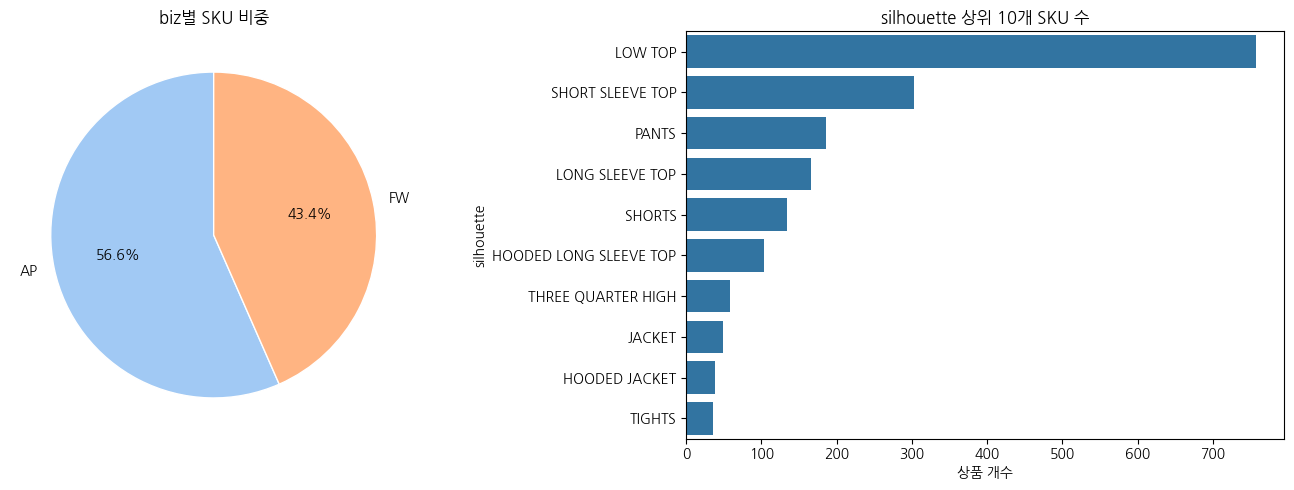

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# biz 파이차트
biz_counts = eda['biz'].value_counts()
axes[0].pie(
    biz_counts,
    labels=biz_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor':'white'}
)
axes[0].set_title('biz별 SKU 비중')

# silhouette 상위 10
top_sil = eda['silhouette'].value_counts().head(10).index
sns.countplot(
    data=eda[eda['silhouette'].isin(top_sil)],
    y='silhouette',
    order=eda['silhouette'].value_counts().head(10).index,
    ax=axes[1]
)
axes[1].set_title('silhouette 상위 10개 SKU 수')
axes[1].set_xlabel('상품 개수')
axes[1].set_ylabel('silhouette')

plt.tight_layout()
plt.show()


### ship_date 분포 / 월별 입고 추이 (오래된 재고 아직 있음 근거)

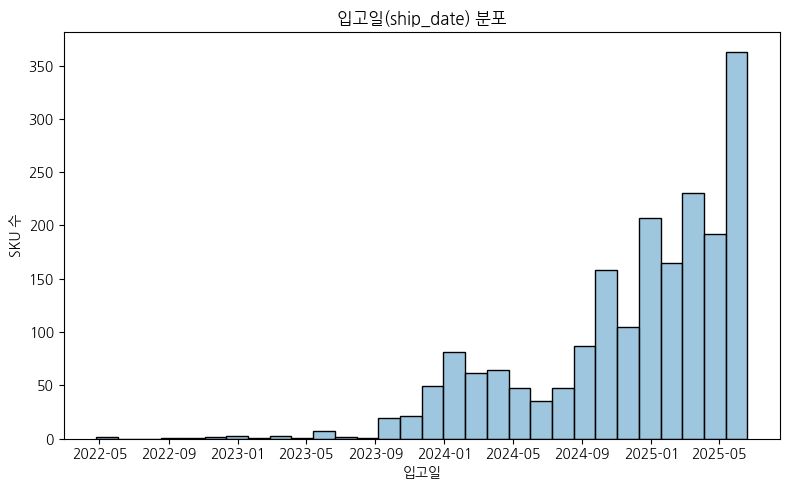

In [86]:
# 입고일 분포 ship_date 히스토그램

plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,5))
sns.histplot(
    data=eda,
    x='ship_date',
    bins=30,
    kde=False,
    color='#7FB3D5'
)
plt.title('입고일(ship_date) 분포')
plt.xlabel('입고일')
plt.ylabel('SKU 수')
plt.tight_layout()
plt.show()


### qty , sale_qty 상관관계

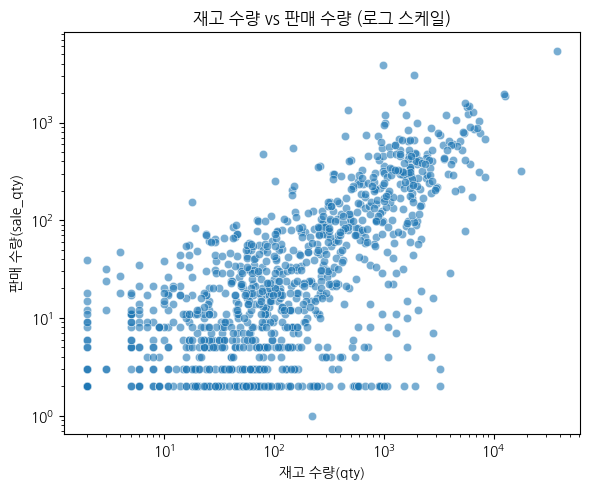

피어슨 상관계수:
              qty  sale_qty
qty       1.00000   0.72302
sale_qty  0.72302   1.00000


In [87]:
# qty , sale_qty > 로그 변환(기존 그래프는 읽기 힘듦)

plt.figure(figsize=(6,5))
sns.scatterplot(data=eda, x='qty', y='sale_qty', alpha=0.6)
plt.xscale('log')
plt.yscale('log')

plt.title('재고 수량 vs 판매 수량 (로그 스케일)')
plt.xlabel('재고 수량(qty)')
plt.ylabel('판매 수량(sale_qty)')
plt.tight_layout()
plt.show()


# 상관계수
print("피어슨 상관계수:")
print(eda[['qty','sale_qty']].corr(method='pearson'))


## EDA 정리

In [88]:
# 1. sake_qty가 음수인 항목이 17개 발견됨 > 환불일 것이라고 가정(제거하고 df_return에 따로 저장)
# 2. null값과 중복되는 값은 없으며 분류가 잘못 되지도 않음
# 3. ship_date가 2022년 2023년인 값도 존재(2025: 1042, 2024: 820, 2023 :106, 2022: 7) 아직 부진 재고에 대한 정의를 하지 않았지만 이 값들은 부진 재고일 가능성이 큼(최근 3개월(2025-03~2025-05) 입고된 상품이 다수를 차지)
# 즉, 신규 입고와 장기 보유 재고가 함께 존재한다고 판단.

# 4. qty과 sale_qty의 상관계수는 0.72 > 일반적으로 재고가 많을 수록 판매량도 많아짐 (단, 일부 품복은 재고 대비 판매 부진)

# 5 의류(AP)군은 재고 규모가 크고 판매량도 비례하는 반면, FW 신발군은 재고 대비 판매 비중이 낮아 시즌성 부진 재고 가능성이 높다.
# 특히 재고는 많은데 판매율을 적은 SKIRT, Pants, BRA 등은 회전율이 현저히 낮은 구간



#1. 1.문제 정의
"부진 재고"의 의미를 정의하고 근거를 제시

## 1-1. 문제 정의 전 시장 조사

### 회계에서 부진 재고 정의
회계에서는 부진 재고를 **가치가 하락했으나 아직 폐기되지 않은 재고**로 봅니다.  
즉, 재고자산의 장부금액이 순실현가능가치보다 낮아진 경우,  
그 차액을 **재고자산 평가손실**로 인식합니다.  
(출처 : IFRS(국제회계기준) 제1002호 「재고자산」)

IFRS 정의는 사후적 손실 인식에 초점을 맞추므로, 본 과제의 목표인 '부진 재고의 조기 식별'에 부합하지 않습니다. 따라서 사전 예측을 위한 새로운 정의가 필요합니다.

---

### 시즌 고려
스포츠 용품의 판매는 계절 주기에 따라 크게 변동합니다.
동일한 판매율이라도 시즌 시점에 따라 의미가 달라지므로,
상품군별 주기 특성을 고려해 재고 회전 속도를 해석했습니다.

일반적으로 시즌은 SS(Spring/Summer) 과 FW(Fall/Winter) 로 구분되며,
시즌 종료 이후에도 재고가 잔존하는 경우는
정상적인 회전이 이루어지지 않은 상태로 판단할 수 있습니다.

---

### 산업 고려
스포츠 산업에서는 **상품군별로 수요 패턴과 회전 주기**가 다릅니다.  
특히 신발(FW)과 의류(AP)는 회전 속도와 재고 리스크의 성격이 뚜렷하게 다릅니다.

- **신발(FW)** : 단가가 높고, 재구매 주기가 길며, 회전 속도가 느림  
- **의류(AP)** : 유행 변화가 빠르고, 시즌 종료 후 재고 리스크가 큼  

이러한 차이를 반영하기 위해,  
분석에서는 상품군(biz)과 실루엣(silhouette)을 함께 고려해  
동일 특성을 가진 그룹 단위로 재고 회전 속도를 비교하고자 했습니다.

## 1-2. 문제 정의
### 데이터 관점에서의 부진 재고 정의
위의 산업적 특성을 종합했을 때
(시즌적 특성은 해당 데이터에서 명확하게 확정할 수 없어 산업적 특성만을 반영했습니다),

데이터 분석에서는 다음과 같이 부진 재고를 정의했습니다.

---
> **부진 재고 :  동일 상품군(biz + silhouette) 내에서 정상 회전 속도에 비해 판매율이 낮거나, 입고 후 경과일이 길어 회전이 정체된 재고**

---
각 상품군별 회전 속도(판매율, 경과일)의 분포가 상이하므로,  
부진 재고의 판별 기준은 절대값이 아닌

**그룹 내 상대적 기준(분위수 기반)으로 설정했습니다**

이를 통해 단순히 “판매가 안 된 상품”이 아니라,  
**정상적인 회전 흐름에서 벗어난 상품**을 정량적으로 구분하고자 했습니다.


# 2.분석 방법론 선택 > KPI,파생 변수 생성

저는 분류 방식으로는 아래 3가지를 검토했습니다
1. **클러스터링**
2. **임계값 기반 분류**
3. **스코어링**  

---
**클러스터링**은 정의된 부진 재고 분류 목표(지도 학습적 성격)에 부적합하므로 제외했습니다.

**임계값 기반 분류**는 단순하지만. 절대값 기준을 적용할 경우 상품군 별 특징을 드러내기 못한다고 생각했습니다

따라서 저는 **그룹 내 상대 비교를 통한 스코어링 방식**을 선택했습니다.

---
# KPI,파생 변수 생성
그리고 이에 따른 필요한 지표와 변수를 생성하였습니다



In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1958 entries, 0 to 1974
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   biz           1958 non-null   object        
 1   product_code  1958 non-null   object        
 2   gender        1958 non-null   object        
 3   silhouette    1958 non-null   object        
 4   qty           1958 non-null   int64         
 5   sale_qty      1958 non-null   int64         
 6   ship_date     1958 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 122.4+ KB


In [90]:
df_raw = df.copy()

In [91]:
# KPI생성
print(df.shape)

## 계산
df['sale_rate'] = np.where(df['qty']>0, df['sale_qty']/df['qty'], np.nan)
df['days_since_ship'] = (pd.Timestamp('2025-06-20') - df['ship_date']).dt.days
print(df.shape)

# 변수 생성
## 그룹 기준
df['category_type'] = df['biz'] + '_' + df['silhouette']
print(df.shape)

## 그룹 내 순위
df['sale_rank_in_group'] = df.groupby('category_type')['sale_rate'].rank(pct=True)
df['days_rank_in_group'] = df.groupby('category_type')['days_since_ship'].rank(pct=True)
print(df.shape)

(1958, 7)
(1958, 9)
(1958, 10)
(1958, 12)


In [92]:
df[['sale_rate','days_since_ship']]

,sale_rate,days_since_ship
0,0.000000,501
1,0.000000,300
2,0.000000,253
3,0.000000,127
4,0.164441,73
...,...,...
1970,0.074989,32
1971,0.000000,270
1972,0.057775,2
1973,0.000000,1


# 3.분류 로직 구축
가중치와 임계값을 제품 특성(의류,신발)에 맞게 변동가능하도록 설정했습니다

## 스케일링
지표 중 `df['sale_rate']` 는 0과 1사이의 값을 가지는 속성으로 스케일링이 필요 없지만

`df['days_since_ship']`는 스케일링이 필요했습니다(분포가 넓으며 단위 차이로 인한 영향력 과다)

저는 **Standard , MinMax, Robust** 방법을 고려했습니다

우선 Robust는 IQR검증 결과 이상치가 많지 않기에 기각했습니다.(약 2.3%)

변수중 `df['sale_rate']`가 0에서 1사이의 값을 가지고 있으니
`df['days_since_ship']`또한 **MinMaX 스케일링**을 통해 범위를 0~1로 맞추었습니다

단, 상품군별 정규성을 갖추기 위해 그룹별로 스케일링을 진행했습니다


In [93]:
# IQR 기반 이상치 검증
Q1 = df['days_since_ship'].quantile(0.25)
Q3 = df['days_since_ship'].quantile(0.75)

IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

outlier_ratio = (df['days_since_ship'] > upper).mean() * 100
display(Q1, Q3, IQR, upper, round(outlier_ratio,3))

np.float64(66.0)

np.float64(282.0)

np.float64(216.0)

np.float64(606.0)

np.float64(2.298)

In [94]:
from sklearn.preprocessing import MinMaxScaler

def minmax_group(s):
    mms = MinMaxScaler()
    return pd.Series(mms.fit_transform(s.to_frame()).ravel(), index=s.index)

# 그룹별 스케일링
df['days_since_ship_scaled'] = (
    df.groupby('category_type')['days_since_ship']
      .transform(minmax_group)
)

In [95]:
df['days_since_ship_scaled'].describe()

,days_since_ship_scaled
count,1958.000000
mean,0.257446
std,0.239649
min,0.000000
25%,0.076389
50%,0.180905
75%,0.371997
max,1.000000


## 스코어링

In [96]:
# 분류 로직 개발

## 스코어링 (가중치 임의 설정 (변동 가능))

# 가중치: 판매(sale) , 체류(days) > 변동 가능
w_sale = 0.5   # 판매 비중
w_days = 0.5   # 체류 비중

df['slow_score'] = (1 - df['sale_rate']) * w_sale + df['days_since_ship_scaled'] * w_days
print(df.shape)

## 임계값 (변동 가능, 기본 유지)
th_rank = 0.25  # 판매 순위 하위 25%
th_days = 0.6   # 경과일 순위 상위 60%

## 라벨 분류 (분위수 기반)
conditions = [
    (df['sale_rank_in_group'] <= th_rank) & (df['days_rank_in_group'] >= th_days),
    (df['sale_rank_in_group'] <= th_rank),
    (df['days_rank_in_group'] >= th_days)
]
labels = ['복합 부진', '상품 부진', '체류 부진']
df['slow_label'] = np.select(conditions, labels, default='정상')

print(df.shape)
df.info()


(1958, 14)
(1958, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 1958 entries, 0 to 1974
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   biz                     1958 non-null   object        
 1   product_code            1958 non-null   object        
 2   gender                  1958 non-null   object        
 3   silhouette              1958 non-null   object        
 4   qty                     1958 non-null   int64         
 5   sale_qty                1958 non-null   int64         
 6   ship_date               1958 non-null   datetime64[ns]
 7   sale_rate               1958 non-null   float64       
 8   days_since_ship         1958 non-null   int64         
 9   category_type           1958 non-null   object        
 10  sale_rank_in_group      1958 non-null   float64       
 11  days_rank_in_group      1958 non-null   float64       
 12  days_since_ship_scaled  1958 no

# 4.로직 수정

In [97]:
# 전체 비율
df['slow_label'].value_counts(normalize=True)

,proportion
slow_label,
정상,0.473442
체류 부진,0.273749
복합 부진,0.132278
상품 부진,0.120531


## 4-1 그룹별 분포 확인

시장의 평균 부진재고율을 배이스라인으로 두고 점수를 확인하고자 하였습니다.

하지만 국가통계포털과 최신 뉴스 들을 통해 의류 산업에 부진 재고가 늘고 있다는 점을 확인했지만, 정확한 부진재고율까지는 찾을 수 없었습니다.


---
th_rank = 0.25  #판매 순위 하위 25%

th_days = 0.6  #경과일 순위 상위 60%

> 다음과 같이 기준을 정하였을 때 부진 재고의 비중이 50% 이상으로 나와

> 그룹별 분포를 확인해

> 이 원인이 **특정 상품 때문인가 / 전체적인 기조인가**를 파악하고자 하였습니다

In [98]:
# 그룹별 비율
df.groupby('category_type')['slow_label'].value_counts(normalize=True,ascending=False)

category_type              slow_label
AP_BRA                     정상            0.562500
                           복합 부진         0.250000
                           체류 부진         0.156250
                           상품 부진         0.031250
AP_DRESS                   정상            0.600000
                           체류 부진         0.400000
AP_HOODED JACKET           정상            0.447368
                           복합 부진         0.315789
                           상품 부진         0.131579
                           체류 부진         0.105263
AP_HOODED LONG SLEEVE TOP  정상            0.592233
                           체류 부진         0.407767
AP_JACKET                  정상            0.591837
                           체류 부진         0.408163
AP_LONG SLEEVE TOP         정상            0.596386
                           체류 부진         0.403614
AP_PANTS                   정상            0.596774
                           체류 부진         0.403226
AP_SET                     정상            0.636364
                           복합 부진         0.181818
                           체류 부진         0.181818
AP_SHORT SLEEVE TOP        정상            0.468647
                           체류 부진         0.283828
                           상품 부진         0.128713
                           복합 부진         0.118812
AP_SHORTS                  정상            0.432836
                           체류 부진         0.320896
                           상품 부진         0.149254
                           복합 부진         0.097015
AP_SKIRT                   정상            0.500000
                           체류 부진         0.500000
AP_SLEEVELESS TOP          정상            0.500000
                           복합 부진         0.250000
                           체류 부진         0.250000
AP_TANK TOP/SINGLET        정상            0.411765
                           체류 부진         0.352941
                           상품 부진         0.176471
                           복합 부진         0.058824
AP_TIGHTS                  정상            0.472222
                           복합 부진         0.277778
                           체류 부진         0.138889
                           상품 부진         0.111111
AP_VEST                    정상            0.500000
                           체류 부진         0.500000
FW_HIGH TOP                정상            0.588235
                           체류 부진         0.411765
FW_LOW TOP                 정상            0.381770
                           복합 부진         0.231176
                           상품 부진         0.216645
                           체류 부진         0.170410
FW_THREE QUARTER HIGH      정상            0.593220
                           체류 부진         0.406780
Name: proportion, dtype: float64

In [99]:
check = df.groupby('category_type')['slow_label'].value_counts(normalize=True).reset_index(name='ratio')
check = check.sort_values('ratio',ascending=False)
check

,category_type,slow_label,ratio
18,AP_SET,정상,0.636364
4,AP_DRESS,정상,0.600000
16,AP_PANTS,정상,0.596774
14,AP_LONG SLEEVE TOP,정상,0.596386
50,FW_THREE QUARTER HIGH,정상,0.593220
10,AP_HOODED LONG SLEEVE TOP,정상,0.592233
12,AP_JACKET,정상,0.591837
44,FW_HIGH TOP,정상,0.588235
0,AP_BRA,정상,0.562500
30,AP_SKIRT,체류 부진,0.500000


In [100]:
check.tail()

,category_type,slow_label,ratio
41,AP_TIGHTS,상품 부진,0.111111
9,AP_HOODED JACKET,체류 부진,0.105263
28,AP_SHORTS,복합 부진,0.097015
37,AP_TANK TOP/SINGLET,복합 부진,0.058824
3,AP_BRA,상품 부진,0.031250


In [101]:
check = df.groupby('category_type')['slow_label'].value_counts(normalize=True).reset_index(name='ratio')
check = check[check['slow_label'] != '정상'].sort_values('ratio',ascending=False)
check.head(10)

,category_type,slow_label,ratio
30,AP_SKIRT,체류 부진,0.500000
43,AP_VEST,체류 부진,0.500000
45,FW_HIGH TOP,체류 부진,0.411765
13,AP_JACKET,체류 부진,0.408163
11,AP_HOODED LONG SLEEVE TOP,체류 부진,0.407767
51,FW_THREE QUARTER HIGH,체류 부진,0.406780
15,AP_LONG SLEEVE TOP,체류 부진,0.403614
17,AP_PANTS,체류 부진,0.403226
5,AP_DRESS,체류 부진,0.400000
35,AP_TANK TOP/SINGLET,체류 부진,0.352941


In [102]:
check.tail()

,category_type,slow_label,ratio
41,AP_TIGHTS,상품 부진,0.111111
9,AP_HOODED JACKET,체류 부진,0.105263
28,AP_SHORTS,복합 부진,0.097015
37,AP_TANK TOP/SINGLET,복합 부진,0.058824
3,AP_BRA,상품 부진,0.031250


## 4-2 결과
상품군에 따라 부진율의 차이가 크지 않으며,

특히 체류 부진의 비중이 높다는 점을 봤을 때,

전반적으로 체류 기간이 길고 재고 회전 속도가 느린 특성을 가지고 있다고 생각했습니다

> 이 현상이 단순 시즌(산업상 판매 회전이 느린 시즌)에 영향인지 / 기업 구조 영향인지는 파악할 수 없으나 입고 주기 데이터나 판매 추이를 보면 명확히 구분할 수 있을 것으로 보입니다

## 4-3 제품군별로 로직 수정

하지만 지금 방식은 앞서 말한 산업군에 대한 고려가 들어가지 않은 분석으로

**전반적인 구조를 파악하기 위한 수단**이었습니다.


그래서 제품군 특성(의류,신발)에 따른 스코어를 다르게 줘


각 그룹의 회전구조를 현실적으로 보고자 하였습니다



In [103]:
# ## 변동 가능(단순 구조 확인용)

# th_days = 0.6 # 경과일 순위 상위 60%
# th_rank = 0.25 # 판매 순위 하위 25%


# ## 라벨 분류 (분위수 기반)
# conditions = [
#     (df['sale_rank_in_group'] <= th_rank) & (df['days_rank_in_group'] >= th_days),
#     (df['sale_rank_in_group'] <= th_rank),
#     (df['days_rank_in_group'] >= th_days)
# ]
# labels = ['복합 부진', '상품 부진', '체류 부진']
# df['slow_label'] = np.select(conditions, labels, default='정상')

# print(df.shape)
# df.info()

In [104]:
# 제품 특성을 반영한 임계값 수정

# # th_days = 0.6 # 경과일 순위 상위 60%
# # th_rank = 0.25 # 판매 순위 하위 25%

# # 신발(FW) : 단가가 높고, 재구매 주기가 길며, 회전 속도가 느림 > rank : 완화(낮춤), days : 완화(높임)
# # 의류(AP) : 유행 변화가 빠르고, 시즌 종료 후 재고 리스크가 큼 > 유지

df['slow_score'] = (1 - df['sale_rank_in_group']) * 0.5 + df['days_rank_in_group'] * 0.5  # 임의로 가중치 설정

th_map = {
    'AP': {'rank': 0.25, 'days': 0.60},
    'FW': {'rank': 0.20, 'days': 0.65},
}

df['th_rank'] = df['biz'].map(lambda b: th_map.get(b, th_map['AP'])['rank'])
df['th_days'] = df['biz'].map(lambda b: th_map.get(b, th_map['AP'])['days'])

# 2) 라벨 분류 (행별 임계값 적용)
# score 분위수(그룹 내 상대 기준)
df['score_rank_in_group'] = (
    df.groupby('category_type')['slow_score'].rank(pct=True, ascending=True)
)

# 예시 임계값 (그리드서치로 다시 튜닝 가능)
th_rank  = 0.25  # 판매 하위 25%
th_score = 0.60  # score 상위 40%

cond_complex = (df['sale_rank_in_group'] <= th_rank) & (df['score_rank_in_group'] >= th_score)
cond_product = (df['sale_rank_in_group'] <= th_rank) & (df['score_rank_in_group'] <  th_score)
cond_stay    = (df['sale_rank_in_group'] >  th_rank) & (df['score_rank_in_group'] >= th_score)

df['slow_label'] = np.select(
    [cond_complex, cond_product, cond_stay],
    ['복합 부진','상품 부진','체류 부진'],
    default='정상'
)


In [105]:
df['slow_label'].value_counts(normalize=True)
display(df['slow_label'].value_counts(normalize=True))
# print(df.groupby('biz')['slow_label'].value_counts(normalize=True).round(3))
display(df.groupby('biz')['slow_label'].value_counts(normalize=True).round(3))

,proportion
slow_label,
정상,0.540858
체류 부진,0.206333
복합 부진,0.197140
상품 부진,0.055669


biz  slow_label
AP   정상            0.555
     체류 부진         0.304
     복합 부진         0.100
     상품 부진         0.041
FW   정상            0.522
     복합 부진         0.324
     체류 부진         0.079
     상품 부진         0.075
Name: proportion, dtype: float64

In [106]:
# 제품 특성을 반영한 가중치 수정 + 임계

# # th_days = 0.6 # 경과일 순위 상위 60%
# # th_rank = 0.25 # 판매 순위 하위 25%

# # 신발(FW) : 단가가 높고, 재구매 주기가 길며, 회전 속도가 느림 > rank : 완화(낮춤), days : 완화(높임)
# # 의류(AP) : 유행 변화가 빠르고, 시즌 종료 후 재고 리스크가 큼 > 유지

df_w = df.copy()

df_w['slow_score_AP'] = (1 - df_w['sale_rank_in_group']) * 0.4 + df_w['days_rank_in_group'] * 0.6
df_w['slow_score_FW'] = (1 - df_w['sale_rank_in_group']) * 0.7 + df_w['days_rank_in_group'] * 0.3

df_w['slow_score'] = np.where(
    df_w['biz'].eq('AP'), df_w['slow_score_AP'],
    np.where(df_w['biz'].eq('FW'), df_w['slow_score_FW'],
             (1 - df_w['sale_rank_in_group']) * 0.5 + df_w['days_rank_in_group'] * 0.5)  # 기타 fallback
)

# 가중치 반영 점수의 그룹 내 분위순위 생성
df_w['score_rank_in_group'] = (
    df_w.groupby('category_type')['slow_score'].rank(pct=True)
)

th_map = {
    'AP': {'rank': 0.25, 'days': 0.60},
    'FW': {'rank': 0.20, 'days': 0.65},
}
df_w['th_rank'] = df_w['biz'].map(lambda b: th_map.get(b, th_map['AP'])['rank'])
df_w['th_days'] = df_w['biz'].map(lambda b: th_map.get(b, th_map['AP'])['days'])  # 보관(호환성)

th_score_map = {'AP': 0.60, 'FW': 0.65}
df_w['th_score'] = df_w['biz'].map(lambda b: th_score_map.get(b, 0.60))

# 2) 라벨 분류 (행별 임계값 적용)
cond_complex = (df_w['sale_rank_in_group'] <= df_w['th_rank']) & (df_w['score_rank_in_group'] >= df_w['th_score'])
cond_product = (df_w['sale_rank_in_group'] <= df_w['th_rank']) & (df_w['score_rank_in_group'] <  df_w['th_score'])
cond_stay    = (df_w['sale_rank_in_group'] >  df_w['th_rank']) & (df_w['score_rank_in_group'] >= df_w['th_score'])

conditions = [cond_complex, cond_product, cond_stay]
labels     = ['복합 부진', '상품 부진', '체류 부진']
df_w['slow_label'] = np.select(conditions, labels, default='정상')


df_w['slow_label'].value_counts(normalize=True)
display(df_w['slow_label'].value_counts(normalize=True))
# print(df.groupby('biz')['slow_label'].value_counts(normalize=True).round(3))
display(df_w.groupby('biz')['slow_label'].value_counts(normalize=True).round(3))


,proportion
slow_label,
정상,0.586823
체류 부진,0.333504
복합 부진,0.049030
상품 부진,0.030644


biz  slow_label
AP   정상            0.538
     체류 부진         0.321
     복합 부진         0.087
     상품 부진         0.054
FW   정상            0.651
     체류 부진         0.349
Name: proportion, dtype: float64

## 4-4 결과
제품군 특성(의류/신발)을 반영하여 임계값과 가중치를 조정한 결과,

부진 재고의 비율이 **이전 대비 조금 더 현실적인 수준**으로 조정되었습니다


다만, 임의로 가중치와 임계값을 설정하는 방식은 **분석자의 주관 개입 가능성이 높아 재현성 및 객관성이 낮다**는 한계가 있습니다.

따라서 가중치와 임계값은 **기업의 실제 운영 구조**(재고 관리 기준 등)를 종합적으로 고려하여 결정하는 것이 타당하다고 생각합니다.


이 과제에서는 내부 구조 정보를 활용할 수 없었기에, **객관성 확보**를 위해 **AI 기반 Grid Search**를 통해 데이터 중심의 최적 임계값과 가중치 조합을 탐색하여 모델을 완성했습니다.



## 4-5 그리드 서치 진행
#### 목적: 전체 부진률을 목표 구간으로 맞추고(AP/FW 구조 반영), 결과 안정적/설명가능하게
####  입력 전제: df[biz, category_type, sale_rank_in_group, days_rank_in_group] 존재

In [107]:
# 파라미터 후보 범위 성정
## AP(의류)는 기준을 엄격하게 , 신발은 기준을 느슨하게 설정

## 가중치
grid_w_sale_AP = np.array([0.31, 0.41, 0.51, 0.60])
grid_w_sale_FW = np.array([0.61, 0.71, 0.80])

## 임계값(판매)
grid_th_rank_AP  = np.array([0.22, 0.24, 0.26, 0.28])
grid_th_rank_FW  = np.array([0.18, 0.20, 0.22])    #신발은 판매 낮은 제품이 정상일 수 있음


## 임계값(체류)
grid_th_score_AP = np.array([0.58, 0.60, 0.62, 0.64, 0.66])
grid_th_score_FW = np.array([0.63, 0.65, 0.67, 0.68])    #신발은 체류일 길어도 정상 가능성 높음

## 목표 제약
TARGET_BAD = 0.35
RANGE_BAD = (0.35, 0.45)
MAX_COMPLEX = 0.22

# 3. 라벨링 함수 정의
def label_with_params(df_in,
                      w_sale_AP, w_sale_FW,
                      th_rank_AP, th_rank_FW,
                      th_score_AP, th_score_FW):
    df_w = df_in.copy()

    # 가중치
    w_days_AP = 1.0 - w_sale_AP
    w_days_FW = 1.0 - w_sale_FW

    # 👉 rank 대신: 실값 + MinMax(그룹별) 기반 점수
    slow_score_AP = (1 - df_w['sale_rate']) * w_sale_AP + df_w['days_since_ship_scaled'] * w_days_AP
    slow_score_FW = (1 - df_w['sale_rate']) * w_sale_FW + df_w['days_since_ship_scaled'] * w_days_FW

    df_w['slow_score'] = np.where(
        df_w['biz'].eq('AP'), slow_score_AP,
        np.where(df_w['biz'].eq('FW'), slow_score_FW,
                 (1 - df_w['sale_rate']) * 0.5 + df_w['days_since_ship_scaled'] * 0.5)  # fallback
    )

    # score 분위수는 새로운 slow_score로 계산
    df_w['score_rank_in_group'] = df_w.groupby('category_type')['slow_score'].rank(pct=True)

    # biz별 임계 적용
    df_w['th_rank']  = np.where(df_w['biz'].eq('AP'), th_rank_AP,  th_rank_FW)
    df_w['th_score'] = np.where(df_w['biz'].eq('AP'), th_score_AP, th_score_FW)

    cond_complex = (df_w['sale_rank_in_group'] <= df_w['th_rank']) & (df_w['score_rank_in_group'] >= df_w['th_score'])
    cond_product = (df_w['sale_rank_in_group'] <= df_w['th_rank']) & (df_w['score_rank_in_group'] <  df_w['th_score'])
    cond_stay    = (df_w['sale_rank_in_group'] >  df_w['th_rank']) & (df_w['score_rank_in_group'] >= df_w['th_score'])

    df_w['slow_label'] = np.select(
        [cond_complex, cond_product, cond_stay],
        ['복합 부진','상품 부진','체류 부진'],
        default='정상'
    )
    return df_w

# === 4. 스코어 최적화 계산 함수 정의 (evaluate) ===
# 목적함수 가중치/표기 자리수
W_PROX, W_SEP, W_BAL = 2.0, 1.0, 0.5   # 근접성, 분리도, 균형
ROUND_P, ROUND_S = 4, 6

def evaluate(df_labeled):
    # 전체 분포
    vc = df_labeled['slow_label'].value_counts(normalize=True)
    bad_ratio     = float(1 - vc.get('정상', 0.0))
    product_ratio = float(vc.get('상품 부진', 0.0))
    stay_ratio    = float(vc.get('체류 부진', 0.0))   # ※ 라벨명이 '시즌 부진'이면 여기/아래도 동일하게 바꿔.
    complex_ratio = float(vc.get('복합 부진', 0.0))

    # 비즈별 분포 (각 그룹 내 정규화)
    g = (df_labeled.groupby('biz')['slow_label']
                   .value_counts(normalize=True)
                   .rename('p').reset_index())

    def p(b, l):
        s = g[(g['biz']==b) & (g['slow_label']==l)]['p']
        return float(s.iloc[0]) if not s.empty else 0.0

    ap_prod = p('AP','상품 부진')
    ap_stay = p('AP','체류 부진')
    fw_stay = p('FW','체류 부진')
    fw_comp = p('FW','복합 부진')

    # 제약식 (전역 상수 사용: RANGE_BAD, TARGET_BAD, MAX_COMPLEX)
    constraints_ok = (
        (RANGE_BAD[0] <= bad_ratio <= RANGE_BAD[1]) and
        (ap_stay >= ap_prod) and
        (fw_comp >= fw_stay) and
        (complex_ratio <= MAX_COMPLEX)
    )

    # 목적함수 구성
    proximity  = -abs(bad_ratio - TARGET_BAD)  # 목표 부진율 근접성 (높을수록 좋음)
    separation = (fw_comp - p('AP','복합 부진')) + (ap_stay - fw_stay)  # 비즈 간 라벨 특성 분리도
    balance    = -(max(product_ratio, stay_ratio, complex_ratio) -
                   min(product_ratio, stay_ratio, complex_ratio))        # 라벨 분포 균형

    score = (W_PROX * proximity) + (W_SEP * separation) + (W_BAL * balance)
    if not constraints_ok:
        score -= 100.0  # 하드 페널티

    return {
        'bad_ratio':     round(bad_ratio, ROUND_P),
        'complex_ratio': round(complex_ratio, ROUND_P),
        'score':         round(score, ROUND_S),
        'constraints_ok': constraints_ok,
    }


In [108]:
# 5. 그리드 탐색 실행 및 결과 출력
records = []
total_combinations = (len(grid_w_sale_AP) * len(grid_w_sale_FW) *
                      len(grid_th_rank_AP) * len(grid_th_rank_FW) *
                      len(grid_th_score_AP) * len(grid_th_score_FW))

print(f"총 {total_combinations}개의 조합을 탐색합니다.")

for w_ap in grid_w_sale_AP:
    for w_fw in grid_w_sale_FW:
        for r_ap in grid_th_rank_AP:
            for r_fw in grid_th_rank_FW:
                for s_ap in grid_th_score_AP:
                    for s_fw in grid_th_score_FW:
                        df_try = label_with_params(df,
                                                     w_sale_AP=w_ap, w_sale_FW=w_fw,
                                                     th_rank_AP=r_ap, th_rank_FW=r_fw,
                                                     th_score_AP=s_ap, th_score_FW=s_fw)
                        met = evaluate(df_try)
                        met.update({
                            'w_sale_AP': w_ap, 'w_days_AP': round(1-w_ap,2),
                            'w_sale_FW': w_fw, 'w_days_FW': round(1-w_fw,2),
                            'th_rank_AP': r_ap, 'th_rank_FW': r_fw,
                            'th_score_AP': s_ap, 'th_score_FW': s_fw
                        })
                        records.append(met)

results = pd.DataFrame(records).sort_values('score', ascending=False).reset_index(drop=True)

print("\n--- 상위 10개 최적 조합 후보 확인 ---")
display(results.head(10))

best = results.iloc[0].to_dict()
print("\nBest params (Score 기준 최적 조합):")
print({k: best[k] for k in ['w_sale_AP','w_days_AP','w_sale_FW','w_days_FW','th_rank_AP','th_rank_FW','th_score_AP','th_score_FW','bad_ratio','complex_ratio','score']})

df_best = label_with_params(
    df,
    w_sale_AP=best['w_sale_AP'], w_sale_FW=best['w_sale_FW'],
    th_rank_AP=best['th_rank_AP'], th_rank_FW=best['th_rank_FW'],
    th_score_AP=best['th_score_AP'], th_score_FW=best['th_score_FW']
)

print("-- 최종 라벨 분포 --")
print((df_best['slow_label'].value_counts(normalize=True)*100).round(1))
print("-- 제품군별 라벨 분포 --")
print(df_best.groupby('biz')['slow_label'].value_counts(normalize=True).mul(100).round(1))

총 2880개의 조합을 탐색합니다.

--- 상위 10개 최적 조합 후보 확인 ---


,bad_ratio,complex_ratio,score,constraints_ok,w_sale_AP,w_days_AP,w_sale_FW,w_days_FW,th_rank_AP,th_rank_FW,th_score_AP,th_score_FW
0,0.3641,0.0383,-100.271305,False,0.31,0.69,0.71,0.29,0.22,0.20,0.66,0.68
1,0.3641,0.0383,-100.271305,False,0.31,0.69,0.71,0.29,0.22,0.22,0.66,0.68
2,0.3641,0.0383,-100.271305,False,0.31,0.69,0.71,0.29,0.22,0.18,0.66,0.68
3,0.3647,0.0383,-100.273758,False,0.31,0.69,0.61,0.39,0.22,0.18,0.66,0.68
4,0.3647,0.0383,-100.273758,False,0.31,0.69,0.61,0.39,0.22,0.22,0.66,0.68
5,0.3647,0.0383,-100.273758,False,0.31,0.69,0.61,0.39,0.22,0.20,0.66,0.68
6,0.3616,0.0409,-100.275223,False,0.41,0.59,0.71,0.29,0.22,0.20,0.66,0.68
7,0.3616,0.0409,-100.275223,False,0.41,0.59,0.71,0.29,0.22,0.22,0.66,0.68
8,0.3616,0.0409,-100.275223,False,0.41,0.59,0.71,0.29,0.22,0.18,0.66,0.68
9,0.3652,0.0383,-100.276211,False,0.31,0.69,0.80,0.20,0.22,0.22,0.66,0.68



Best params (Score 기준 최적 조합):
{'w_sale_AP': 0.31, 'w_days_AP': 0.69, 'w_sale_FW': 0.71, 'w_days_FW': 0.29, 'th_rank_AP': 0.22, 'th_rank_FW': 0.2, 'th_score_AP': 0.66, 'th_score_FW': 0.68, 'bad_ratio': 0.3641, 'complex_ratio': 0.0383, 'score': -100.271305}
-- 최종 라벨 분포 --
slow_label
정상       63.6
체류 부진    29.6
복합 부진     3.8
상품 부진     3.0
Name: proportion, dtype: float64
-- 제품군별 라벨 분포 --
biz  slow_label
AP   정상            60.2
     체류 부진         27.8
     복합 부진          6.8
     상품 부진          5.2
FW   정상            68.0
     체류 부진         32.0
Name: proportion, dtype: float64


# 5 결과 및 인사이트

### 1. 라벨 분포 요약
- 전체 재고 중 **정상 63.6%**, **체류 부진 29.6%**, **복합 부진 3.8%**, **상품 부진 3.0%** 로 나타났습니다.  
- 즉, **약 36%의 재고가 부진재고**으로 분류되었으며, 이 중 체류 부진이 가장 큰 비중을 차지하였습니다.  
- 이를 통해 **판매는 일부 있으나 장기 미소진 상태인 재고**가 상당수 존재를 확인했습니다.

---

### 2. 제품군(biz)별 특징
- AP(의류)는 부진 비중이 **39.8%로**, **FW(신발, 32.0%)** 대비 높게 나타났습니다.  
  이는 의류 상품이 시즌성 영향으로 인해 **판매율이 낮고 체류 기간이 긴 상품군이 많기 때문**이라고 생각합니다.  

- FW(신발)은 판매율 가중치를 높이고 체류 임계값을 완화한 결과,  
  **정상 비중이 68%로 높게 유지**되었습니다.  
  다만 **체류 부진이 32% 수준**으로 존재하여, 판매율은 양호하지만 **회전 효율 개선 여지**가 남아 있음을 보여줍니다.  

---

### 3. 라벨별 평균 지표 요약

| 구분 | 판매율(sale_rate) | 체류일(days_since_ship) | 해석 |
|------|---------------|-----------------|------|
| 복합 부진 | 0.00 | 341.97일 | 판매 정체 + 장기 체류 (가장 심각한 유형) |
| 상품 부진 | 0.00 | 13.38일 | **출고된 지 얼마 안 된 초기 저판매 상품군**, 관측 기간이 짧아 0으로 나타남 |
| 체류 부진 | 0.05 | 366.55일 | 일부 판매는 있으나 장기 미소진 상태 |
| 정상 | 0.40 | 130.49일 | 판매율과 체류일이 균형을 유지한 정상 회전군 |

> ※ 전체 판매율이 낮게 나타난 것은, 데이터가 **현재 잔여 재고 기준**으로 구성되어 있고  
> 스포츠 의류 산업의 **3개월 누적 판매율 자체가 낮은 구조**이기 때문이라고 생각합니다.  
---

### 4. 세부 카테고리별 인사이트 (AP 중심)
- **BRA, TIGHTS, SHORT SLEEVE TOP, SHORTS** 등 여름 계열 아이템에서 **복합·상품 부진 비율이 높게** 나타났습니다.  
- 반면 **JACKET, LONG SLEEVE TOP, VEST 등 장기 체류 비중이 높은 상품군**도 존재합니다.  
- 결과적으로, **여름 상품의 초기 저판매 + 겨울 상품의 장기 체류**라는 **이중 부진 패턴**이 관찰되었습니다.  

---

### 5. 종합 인사이트 요약
1. 전체 재고의 약 **36%가 회전 부진군**이며, 이 중 **체류 부진이 30%로 가장 큰 비중**을 차지하였습니다.  
2. 의류(AP)는 신발(FW) 대비 부진 비중이 약 **1.25배 높으며**, 부진 원인은 판매율보다 **체류 기간 증가**가 주된 요인입니다.  
3. 복합 부진(3.8%)은 판매율 0, 체류일 340일 이상으로 **재고 평가손실 위험이 가장 높은 핵심 관리 대상군입니다.**
4. 상품 부진(3.0%)은 **출고 후 2~3주 내 판매가 발생하지 않은 초기 입고 상품군**으로, 단기 추적 모니터링이 필요합니다.  
5. 전반적으로 **시즌 교차형 부진(여름 저판매 + 겨울 장기 체류)** 현상이 나타나,  
   향후 **상품군별 회전 전략 및 시즌별 재고 관리 기준 차등화**가 필요합니다.


# 결과 파일 생성

In [109]:
print(df_best.shape,df_raw.shape)
print(df_best.columns,df_raw.columns)
print(df_best.info(),df_raw.info() )

(1958, 19) (1958, 7)
Index(['biz', 'product_code', 'gender', 'silhouette', 'qty', 'sale_qty',
       'ship_date', 'sale_rate', 'days_since_ship', 'category_type',
       'sale_rank_in_group', 'days_rank_in_group', 'days_since_ship_scaled',
       'slow_score', 'slow_label', 'th_rank', 'th_days', 'score_rank_in_group',
       'th_score'],
      dtype='object') Index(['biz', 'product_code', 'gender', 'silhouette', 'qty', 'sale_qty',
       'ship_date'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 1958 entries, 0 to 1974
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   biz                     1958 non-null   object        
 1   product_code            1958 non-null   object        
 2   gender                  1958 non-null   object        
 3   silhouette              1958 non-null   object        
 4   qty                     1958 non-null   int64         


In [110]:
import numpy as np
from pathlib import Path

df_best = df_best.copy()
if 'slow_label_final' not in df_best.columns:
    df_best['new_item_flag'] = (df_best['days_since_ship'] < 21) & (df_best['sale_rate'] == 0)
    df_best['slow_label_final'] = np.where(df_best['new_item_flag'], '관망', df_best['slow_label'])

# 필요한 파생변수만 선택
cols_attach = ['product_code', 'sale_rate', 'days_since_ship', 'slow_label_final']
cols_attach = [c for c in cols_attach if c in df_best.columns]

# 병합 (df_raw의 모든 컬럼 유지 + 파생변수 3)
df_submit = df_raw.merge(
    df_best[cols_attach],
    on='product_code',
    how='left',
    validate='one_to_one'
)

# 날짜 타입 기존과 동일하게 변경
df_submit['ship_date'] = pd.to_datetime(df_submit['ship_date']).dt.strftime('%Y-%m-%d')

# 컬럼 순서
original_order = list(df_raw.columns)  # ['biz','product_code','gender','silhouette','qty','sale_qty','ship_date']
added_cols = [c for c in ['sale_rate','days_since_ship','slow_label_final'] if c in df_submit.columns]
df_submit = df_submit[original_order + added_cols]

# 저장
today_str = pd.Timestamp.today().strftime('%Y%m%d')
out_path = Path(f"대연_부진재고_분류결과_{today_str}.xlsx")
df_submit.to_excel(out_path, index=False)

#